# ___Phylogenetic traversal of independent ACEs of discrete and continuous traits___
---------------------------------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.5.3 (2026-03-11 ucrt)"


In [2]:
suppressPackageStartupMessages({
    library("ape")
    library("geiger")
    library("phytools")
    library("corHMM")
    library("OUwie")
})

source("../helpers.R")
set.seed(2026 - 2 - 24)

## ___Collab subset with 995 species averages (genus level mycorrhizal state recommendations from FungalRoot)___
---------------------------------

In [3]:
data <- read.csv("../../data/chapter2/FREDv3subset/collab_fineroots_log_995_species_means_5states_name_matched_with_phylogeny.csv")[,
                                c("binominal", "F01286", "F01287", "F01289", "F01290", "F00679", "F00727", "state")]

phylogeny <- ape::multi2di(ape::read.tree("../../data/chapter2/uphylomaker/collab_fineroots_log_995_species_means_5states.tre")) # phylogenetic tree created for the 995 species using U.PhyloMaker
stopifnot(all(data$binominal==phylogeny$tip.label)) # make sure the names match
stopifnot(ape::is.binary(phylogeny))
stopifnot(ape::is.ultrametric(phylogeny))
stopifnot(ape::is.rooted(phylogeny))

RD <- setNames(data$F00679, nm = data$binominal)
SRL <- setNames(data$F00727, nm = data$binominal)

In [66]:
head(data)

,binominal,F01286,F01287,F01289,F01290,F00679,F00727,state
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,Rudbeckia_hirta,Rudbeckia,hirta,Asteraceae,Asterales,-1.3327915,5.694268,AM
2,Ratibida_pinnata,Ratibida,pinnata,Asteraceae,Asterales,-0.8209806,4.025352,AM
3,Heliopsis_helianthoides,Heliopsis,helianthoides,Asteraceae,Asterales,-0.9675840,4.158883,NM
4,Liatris_aspera,Liatris,aspera,Asteraceae,Asterales,-0.7985077,4.382027,AM
5,Arnica_sororia,Arnica,sororia,Asteraceae,Asterales,-1.4134600,4.342257,AM
6,Arnica_fulgens,Arnica,fulgens,Asteraceae,Asterales,-0.6627150,2.765172,AM


## ___ACE of discrete categorical traits using `ape`, `corHMM` & `phytools`___
------------------------------------------------------

In [64]:
table(data$state) # mycorrhizal state distribution


   AM   EcM EcMAM    NM  NMAM 
  778   122    26    20    49 

In [18]:
#----------------------------------------------------------------------------------------------------------------------------------------------------------
# choosing the ARD model for mycorrhizal state evolution as it has been demonstrated that different transitions happen at different rates
# and some transitions are prectically irreversible compared to others
#----------------------------------------------------------------------------------------------------------------------------------------------------------

# create a named vector for the mycorrhizal states for use with ape::ace and phytools::ancr
states <- setNames(data$state, nm=data$binominal)
stopifnot(all(names(states)==phylogeny$tip.label))

# there are multiple ways to do ACE of discrete characters 
# ace_mystates_rr <- phytools::rerootingMethod(tree = phylogeny, x = states, model = "ARD") - phytools::rerootingMethod method should not be used with non-symmetrical rate models of evolution
# read more here - https://blog.phytools.org/2023/06/decommissioning-rerootingmethod-and.html

# we fit each of these models with all of the three evolutionary modes and will do a model comparsion before making the decision

ace_mystates_hmm_er <- corHMM::corHMM(phy = phylogeny, data = data[, c("binominal", "state")], model = "ER", node.states = "marginal", rate.cat = 1)
ace_mystates_hmm_sym <- corHMM::corHMM(phy = phylogeny, data = data[, c("binominal", "state")], model = "SYM", node.states = "marginal", rate.cat = 1)
ace_mystates_hmm_ard <- corHMM::corHMM(phy = phylogeny, data = data[, c("binominal", "state")], model = "ARD", node.states = "marginal", rate.cat = 1)

 # ape::ace used a non traditional way to compute marginal ACEs, see its documentation for more details
# setting marginal = FALSE actually returns the marginal ACEs, see the documentation of ape::ace for more details
ace_mystates_ape_er <- ape::ace(phy = phylogeny, x = states, type = "discrete", method = "ML", model = "ER", marginal = FALSE)
ace_mystates_ape_sym <- ape::ace(phy = phylogeny, x = states, type = "discrete", method = "ML", model = "SYM", marginal = FALSE)
ace_mystates_ape_ard <- ape::ace(phy = phylogeny, x = states, type = "discrete", method = "ML", model = "ARD", marginal = FALSE)

ace_mystates_ancr_er <- phytools::ancr(phytools::fitMk(tree = phylogeny, x = states, model = "ER"))
ace_mystates_ancr_sym <- phytools::ancr(phytools::fitMk(tree = phylogeny, x = states, model = "SYM"))
ace_mystates_ancr_ard <- phytools::ancr(phytools::fitMk(tree = phylogeny, x = states, model = "ARD"))

save(ace_mystates_hmm_er, ace_mystates_hmm_sym, ace_mystates_hmm_ard, # corHMM
        ace_mystates_ape_er, ace_mystates_ape_sym, ace_mystates_ape_ard, # ape
            ace_mystates_ancr_er, ace_mystates_ancr_sym, ace_mystates_ancr_ard, # phytools
                file = "./../../data/chapter2/rdata/ace_states_all_995sp.RData")

You specified 'fixed.nodes=FALSE' but included a phy object with node labels. These node labels have been removed.


Warning message in corHMM::corHMM(phy = phylogeny, data = data[, c("binominal", :
"Branch lengths of 0 detected. Adding 1e-5 to these branches."


State distribution in data:
States:	1	2	3	4	5	
Counts:	778	122	26	20	49	
Beginning thorough optimization search -- performing 0 random restarts 
Finished. Inferring ancestral states using marginal reconstruction. 
You specified 'fixed.nodes=FALSE' but included a phy object with node labels. These node labels have been removed.


Warning message in corHMM::corHMM(phy = phylogeny, data = data[, c("binominal", :
"Branch lengths of 0 detected. Adding 1e-5 to these branches."


State distribution in data:
States:	1	2	3	4	5	
Counts:	778	122	26	20	49	
Beginning thorough optimization search -- performing 0 random restarts 
Finished. Inferring ancestral states using marginal reconstruction. 
You specified 'fixed.nodes=FALSE' but included a phy object with node labels. These node labels have been removed.


Warning message in corHMM::corHMM(phy = phylogeny, data = data[, c("binominal", :
"Branch lengths of 0 detected. Adding 1e-5 to these branches."


State distribution in data:
States:	1	2	3	4	5	
Counts:	778	122	26	20	49	
Beginning thorough optimization search -- performing 0 random restarts 
Finished. Inferring ancestral states using marginal reconstruction. 


Warning message in sqrt(diag(solve(h))):
"NaNs produced"
Warning message in ape::ace(phy = phylogeny, x = states, type = "discrete", method = "ML", :
"model fit suspicious: gradients apparently non-finite"


In [4]:
#-----------------------------
# REUSE THE SAVED MODELS
#-----------------------------

load("../../data/chapter2/rdata/ace_states_all_995sp.RData")

In [5]:
corhmm_ace <- list(ER=ace_mystates_hmm_er, SYM=ace_mystates_hmm_sym, ARD=ace_mystates_hmm_ard)
ape_ace <- list(ER=ace_mystates_ape_er, SYM=ace_mystates_ape_sym, ARD=ace_mystates_ape_ard)
phytools_ace <- list(ER=ace_mystates_ancr_er, SYM=ace_mystates_ancr_sym, ARD=ace_mystates_ancr_ard)

## ___Discrete character evolution model comparison___
-----------------------------

In [6]:
# log likelihoods
data.frame(ape = mapply(ape_ace, FUN = function(model) model$loglik), corHMM = mapply(corhmm_ace, FUN = function(model) model$loglik), phytools = mapply(phytools_ace, FUN = function(model) model$logLik))

,ape,corHMM,phytools
,<dbl>,<dbl>,<dbl>
ER,-234.1680,-235.7775,-235.7775
SYM,-424.8496,-225.6099,-225.6099
ARD,-319.5835,-221.4237,-224.0676


In [7]:
# corHMM AICc
mapply(corhmm_ace, FUN = function(model) model$AICc) # SYM seems to have the lowest AICc

ER      SYM      ARD 
473.5590 471.4434 483.7099

In [11]:
# decide which one to continue with from ER, SYM and ARD; based on AICs?
data.frame(ape = mapply(ape_ace, FUN = stats::AIC), phytools = mapply(phytools_ace, FUN = stats::AIC), corHMM = mapply(corhmm_ace, FUN = function(model) model$AIC)) # stats::AIC() fails for corHMM models

,ape,phytools,corHMM
,<dbl>,<dbl>,<dbl>
ER,470.3361,473.5549,473.5550
SYM,869.6992,471.2198,471.2199
ARD,679.1671,488.1353,482.8475


In [ ]:
# to pick model one over another, the AIC difference must be greater than 2 (according to James Boyko) 
# and 4 according to https://eeob-macroevolution.github.io/Practicals/Fitting_Evol_Models/Fit_Evol_Models_Tutorial.html
# in case, where two models have insignificantly different AIC, it's advised we pick the simplest model

# torn between ER and SYM here ...........

In [8]:
head(ace_mystates_ape_sym$lik.anc) # ACEs from ape::ace 

,AM,EcM,EcMAM,NM,NMAM
,0.9347825,1.409544e-02,1.518461e-02,1.428788e-02,2.164959e-02
,0.9642778,8.507876e-03,8.718810e-03,8.548058e-03,9.947483e-03
Spermatophyta,0.9968460,7.423232e-04,7.649521e-04,7.466208e-04,9.000905e-04
Mesangiospermae,1.0000000,3.973729e-11,6.087225e-10,4.729927e-11,3.272988e-08
mrcaott2ott121,1.0000000,3.602067e-11,2.565054e-10,4.281196e-11,1.088215e-08
eudicotyledons,0.9999999,2.821206e-09,6.770980e-09,3.212890e-09,1.067848e-07


In [9]:
head(ace_mystates_ancr_sym$ace) # ACEs from phytools::ancr

,AM,EcM,EcMAM,NM,NMAM
996,0.8677333,1.615585e-03,8.085863e-05,1.118275e-04,1.304584e-01
997,0.8923773,4.360033e-04,9.129328e-06,1.454970e-05,1.071630e-01
998,0.9844145,2.373842e-04,5.482435e-06,8.774089e-06,1.533390e-02
999,1.0000000,8.303233e-10,3.111731e-10,5.017771e-10,4.317951e-08
1000,1.0000000,2.199400e-10,9.320763e-11,1.562347e-10,1.582668e-08
1001,0.9999999,1.438710e-09,6.915703e-10,8.739834e-09,5.861753e-08


In [29]:
# the output of corHMM lacks explicit column names (mycorrhizal states) but outputs of ape and corHMM lack explicit row names (node numbers)
head(ace_mystates_hmm_sym$states) # ACEs from corHMM

"(1,R1)","(2,R1)","(3,R1)","(4,R1)","(5,R1)"
0.8677180,1.614501e-03,8.088488e-05,1.118081e-04,1.304748e-01
0.8923627,4.356344e-04,9.133608e-06,1.454612e-05,1.071779e-01
0.9844139,2.373409e-04,5.484983e-06,8.771883e-06,1.533451e-02
1.0000000,8.307939e-10,3.113166e-10,5.016449e-10,4.318594e-08
1.0000000,2.201097e-10,9.325261e-11,1.561897e-10,1.582929e-08
0.9999999,1.439827e-09,6.918843e-10,8.737587e-09,5.862592e-08


In [11]:
ace_mystates_hmm_sym


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -225.6099 471.2199 471.4434        1  995

Legend
      1       2       3       4       5 
   "AM"   "EcM" "EcMAM"    "NM"  "NMAM" 

Rates
             (1,R1)       (2,R1)       (3,R1)       (4,R1)       (5,R1)
(1,R1)           NA 0.0002394889 0.0001896233 0.0002213996 0.0007797498
(2,R1) 0.0002394889           NA 0.0000000010 0.0000000010 0.0003261658
(3,R1) 0.0001896233 0.0000000010           NA 0.0000000010 0.0000000010
(4,R1) 0.0002213996 0.0000000010 0.0000000010           NA 0.0000000010
(5,R1) 0.0007797498 0.0003261658 0.0000000010 0.0000000010           NA

Arrived at a reliable solution 

In [12]:
# based on the legend of the corHMM model output
STATES_LEGEND_CORHMM <- c("AM", "EcM", "AMEcM", "NM", "AMNM")
STATES_LEGEND_CORHMM

[1] "AM"    "EcM"   "AMEcM" "NM"    "AMNM"

In [13]:
#-------------------------------------------
# USING THE SYM FLAVOURS
#-------------------------------------------

state_preds_hmm_sym <- STATES_LEGEND_CORHMM[apply(ace_mystates_hmm_sym$states, MARGIN = 1, FUN = which.max)] # MARGIN = 1 is used for row wise apply
state_preds_phy_sym <- colnames(ace_mystates_ancr_sym$ace)[apply(ace_mystates_ancr_sym$ace, MARGIN = 1, FUN = which.max)] # only the output of phytools::ancr has explicit node numbers as row names!!
state_preds_ape_sym <- colnames(ace_mystates_ape_sym$lik.anc)[apply(ace_mystates_ape_sym$lik.anc, MARGIN = 1, FUN = which.max)] # colnames(ace_mystates_ape$lik.anc)

In [14]:
mean(state_preds_ape_sym == state_preds_hmm_sym)

[1] 0.9285714

In [15]:
mean(state_preds_ape_sym == state_preds_phy_sym) # the lowest

[1] 0.9668008

In [16]:
mean(state_preds_phy_sym == state_preds_hmm_sym) # the highest

[1] 0.9476861

In [13]:
all(rownames(ace_mystates_ancr$ace) == 396:789) # internal node names

[1] TRUE

## ___ACE of continuous traits___
------------------------------------------------------

In [ ]:
# as first step, decide which model of continuous trait evolution best explains the evolution of RD & SRL in our dataset

In [15]:
# phytools::fastAnc uses a brownian motion (BM) model for continuous trait evolution

ace_srl_fastanc <- phytools::fastAnc(tree = phylogeny, x = SRL, vars = TRUE, CI = TRUE) # this is a Maximim Likelihood (ML) based method - Brownian motion models which essentially is a Markov process on a continuous scale
# https://eeob-macroevolution.github.io/Practicals/Ancestral_State_Estimation/AncStateEstimation_Tutorial.html
# the link above provides detailed info on ACE, and also recommends incorporating fossil data when available to make the ACE more rigorous
# do we have fossil root trait data???????

# Liam J. Revell's website says that phytools::fastAnc also uses Felsenstein's re-rooting algorithm for ACE of continuous characters - http://www.phytools.org/Cordoba2017/ex/7/Anc-states-continuous.html
# PCMIR (page 224) recommends fitting phytools::fastAnc with vars=TRUE, CI=TRUE as ACE happens with lots of uncertainty, so it's important to know the CIs of each reconstruction
ace_rd_fastanc <- phytools::fastAnc(tree = phylogeny, x = RD, vars = TRUE, CI = TRUE) # repeat the above for RD

In [16]:
# examine the variances and confidence intervals of the ACE of the continuous trait
head(ace_srl_fastanc$CI95)

996,-3.153054,10.667221
997,-2.825290,10.326407
998,-2.421623,9.453410
999,1.526475,5.618044
1000,1.540070,5.616640
1001,1.663560,5.637984


In [17]:
# see if the ACEs fall within the respective 95% CIs (BUT THESE 95% CIs ARE REALLY BROAD?????)
mean(ace_srl_fastanc$CI95[, 2] >= ace_srl_fastanc$ace) # estimates lesses than or equal to the upper bound
mean(ace_srl_fastanc$CI95[, 1] <= ace_srl_fastanc$ace) # estimates greater than or equal to the lower bound

[1] 1

[1] 1

In [18]:
# check the 95% CIs for RD
mean(ace_rd_fastanc$CI95[, 1] <= ace_rd_fastanc$ace) # lower bound <= ACE
mean(ace_rd_fastanc$CI95[, 2] >= ace_rd_fastanc$ace) # upper bound >= ACE

[1] 1

[1] 1

In [26]:
# however phytools::fastAnc models the continuous trait evolution based on a BM process, since hOUwie models it based on an OU process, it'll be helpful to include that too
# http://www.phytools.org/anthrotree/asr/1/
# Lapack routine dgesv: system is exactly singular: U[1013,1013] = 0 - this happens when there are 0 length branches in the phylogeny
# https://github.com/liamrevell/phytools/issues/89
# https://github.com/liamrevell/phytools/issues/172

phytools::anc.ML(tree = phylogeny, model = "OU", x = RD, maxit = 5000)

ERROR: Error in solve.default(C): Lapack routine dgesv: system is exactly singular: U[1013,1013] = 0


In [88]:
# stats::cophenetic(phylogeny)

In [20]:
sum(phylogeny$edge.length <= 0) # damn!!!

[1] 91

In [21]:
edge_length_adjusted_phylogeny <- phylogeny # create a copy
edge_length_adjusted_phylogeny$edge.length[edge_length_adjusted_phylogeny$edge.length <= 0] <- 1e-10 # replace zeroes with a single small positive value
phytools::anc.ML(tree = edge_length_adjusted_phylogeny, model = "OU", x = RD, maxit = 5000) # try again

ERROR: Error in solve.default(C): system is computationally singular: reciprocal condition number = 3.13435e-17


In [22]:
# replacing all the zeroes with one small positive number gave a different error - system is computationally singular: reciprocal condition number = 3.1331e-17
# try using a vector of random positive numbers

replacement_lengths <- rnorm(n=sum(phylogeny$edge.length <= 0), mean = 1.0, sd = 0.05) * 1e-10
stopifnot(all(replacement_lengths > 0))

edge_length_adjusted_phylogeny <- phylogeny
edge_length_adjusted_phylogeny$edge.length[edge_length_adjusted_phylogeny$edge.length <= 0] <- replacement_lengths
phytools::anc.ML(tree = edge_length_adjusted_phylogeny, model = "OU", x = RD, maxit = 5000)

ERROR: Error in solve.default(C): system is computationally singular: reciprocal condition number = 3.0889e-17


In [17]:
# try using the package geiger instead of phytools
# http://phytools.org/mexico2018/ex/5/Cont-char-models.html
# which allows the following models  - "BM","OU","EB","rate_trend","lambda","kappa","delta","mean_trend","white"
# page 98 onwards in Phylogenetic Comparative Methods in R

ace_rd_geiger_BM <- geiger::fitContinuous(phy = phylogeny, dat = RD, model = "BM")
ace_rd_geiger_EB <- geiger::fitContinuous(phy = phylogeny, dat = RD, model = "EB")
ace_rd_geiger_OU <- geiger::fitContinuous(phy = phylogeny, dat = RD, model = "OU")

Warning message in geiger::fitContinuous(phy = phylogeny, dat = RD, model = "EB"):
"
Parameter estimates appear at bounds:
	a"


In [18]:
# inspect the fits

as.data.frame(cbind(BM = c(alpha=NA, ace_rd_geiger_BM$opt), # BM models do not estimate alpha and consequently do not have a $alpha attribute, hence we manually include to match the rows with other model types
                    OU = ace_rd_geiger_OU$opt, EB = ace_rd_geiger_EB$opt))

,BM,OU,EB
,<named list>,<named list>,<named list>
alpha,NA,0.357751,-1e-06
sigsq,0.02521209,0.1556148,0.02522213
z0,-0.9195616,-1.100825,-0.919559
lnL,-1066.482,-614.9794,-1066.49
method,Brent,L-BFGS-B,L-BFGS-B
k,2,3,3
aic,2136.963,1235.959,2138.979
aicc,2136.976,1235.983,2139.004


In [ ]:
# when alpha of a EB model is close to 0.00, the EB model becomes a constant rate BM model
# the model with the lowest AICc is OU, which is great as the hOUwie models also use the OU process to model the continuous trait evolution

In [27]:
# now, repeat all of this for SRL

ace_srl_geiger_BM <- geiger::fitContinuous(phy = phylogeny, dat = SRL, model = "BM")
ace_srl_geiger_EB <- geiger::fitContinuous(phy = phylogeny, dat = SRL, model = "EB") # when you get a "Parameter estimates appear at bounds:	a" warning message, this happens when the alpha is very close to 0.0
# this is okay, and just means BM will be a better fit than the EB model in this case
ace_srl_geiger_OU <- geiger::fitContinuous(phy = phylogeny, dat = SRL, model = "OU")

as.data.frame(cbind(BM = c(alpha=NA, ace_srl_geiger_BM$opt), OU = ace_srl_geiger_OU$opt, EB = ace_srl_geiger_EB$opt))

,BM,OU,EB
,<named list>,<named list>,<named list>
alpha,NA,0.3931003,-1.000004e-06
sigsq,0.1745954,1.068361,0.1746655
z0,3.757083,3.890931,3.757091
lnL,-2029.218,-1529.779,-2029.226
method,Brent,L-BFGS-B,subplex
k,2,3,3
aic,4062.436,3065.557,4064.452
aicc,4062.448,3065.581,4064.476


In [ ]:
# once again, OU seems to be the best fit, which is convenient.

In [35]:
# unfortunately, geiger::fitContinuous does not return the ACE values for internal nodels
ace_srl_geiger_OU |> attributes()

$names
[1] "lik" "bnd" "res" "opt"

$class
[1] "gfit" "list"

In [28]:
phytools::ancr(ace_srl_geiger_OU) # that's not going to help

Warning message in ancr.default(ace_srl_geiger_OU):
"ancr does not know how to handle objects of class  gfit .
ancr does not know how to handle objects of class  list .
"


In [46]:
# so we may have to go back to OUwie to fit the OU models???

## $\delta{t}=log(t_{ancestor})-log(t_{descendant})$

In [67]:
#---------------------------------------------------------------------------------------------------------------------
# test for phylogenetic signal in continuous traits using Bloombergs K test and Pagel's lambda test
#---------------------------------------------------------------------------------------------------------------------

# in Bloomberg's K test, phylogenetic signal is considered high when variance between clades is lesser than the variance within clades; K = 1.000 indicates Brownian motion based evolution

bberg_rd <- phytools::phylosig(tree = phylogeny, x = RD, test = TRUE, nsim = 10000)
bberg_srl <- phytools::phylosig(tree = phylogeny, x = SRL, test = TRUE, nsim = 10000)

print(bberg_rd)
print("---------------------")
print(bberg_srl)


Phylogenetic signal K : 0.0293936 
P-value (based on 10000 randomizations) : 1e-04 



In [68]:
# now using Pagel's lambda tests
# lambda < 1 means that less phylogenetic signal than expected under a Brownian motion model of evolution

pagels_rd <- phytools::phylosig(tree = phylogeny, x = RD, method = "lambda", test = TRUE)
pagels_srl <- phytools::phylosig(tree = phylogeny, x = SRL, method = "lambda", test = TRUE)

print(pagels_rd)
print("---------------------")
print(pagels_srl)


Phylogenetic signal lambda : 0.759244 
logL(lambda) : -529.273 
LR(lambda=0) : 225.045 
P-value (based on LR test) : 7.17648e-51 


Phylogenetic signal lambda : 0.69241 
logL(lambda) : -1459.39 
LR(lambda=0) : 207.528 
P-value (based on LR test) : 4.75652e-47 



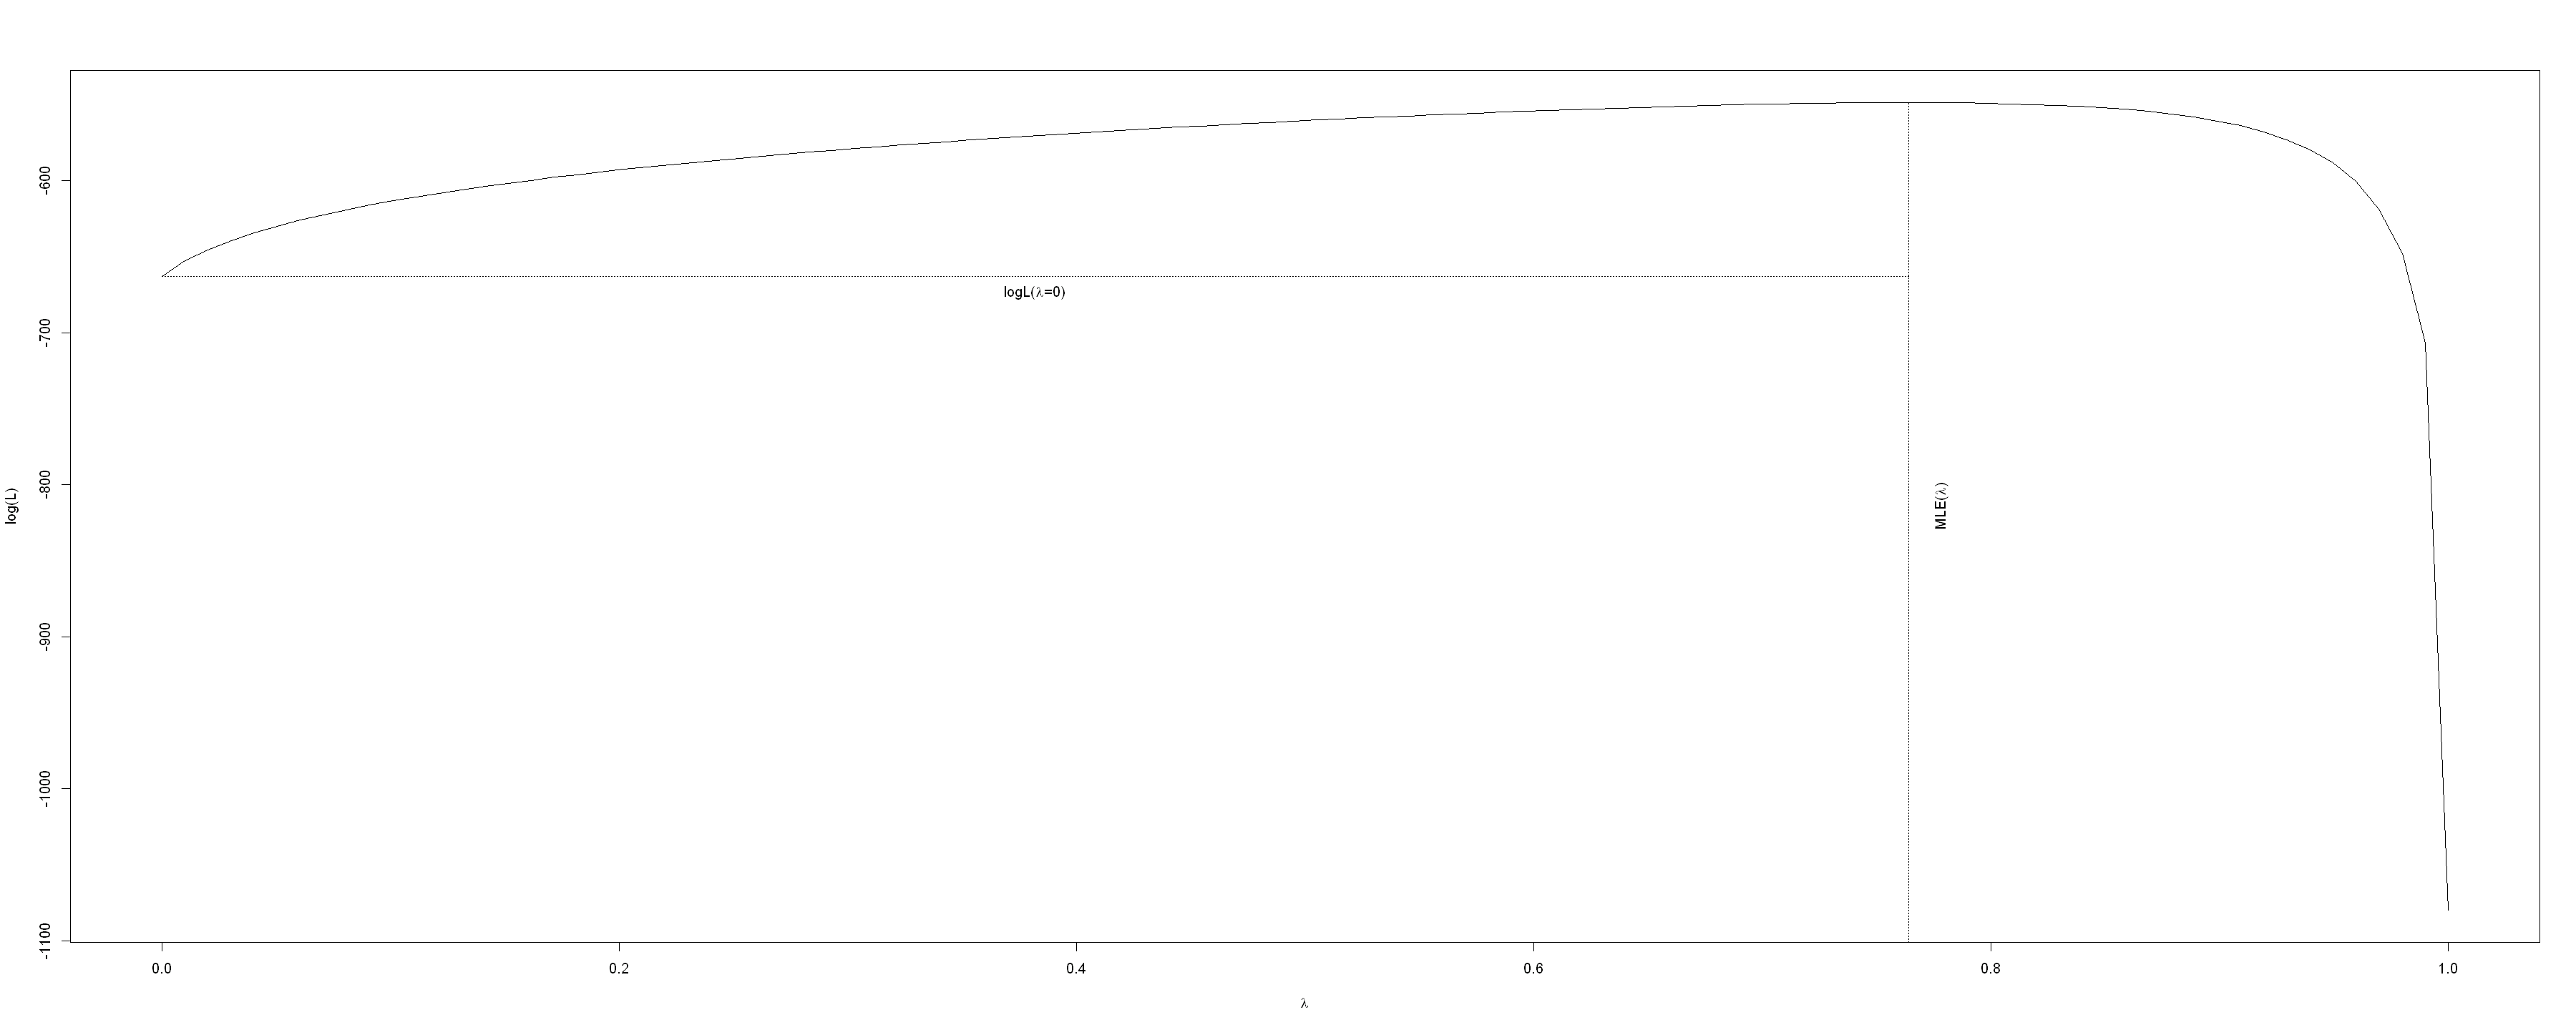

In [106]:
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 400)
plot(pagels_rd)

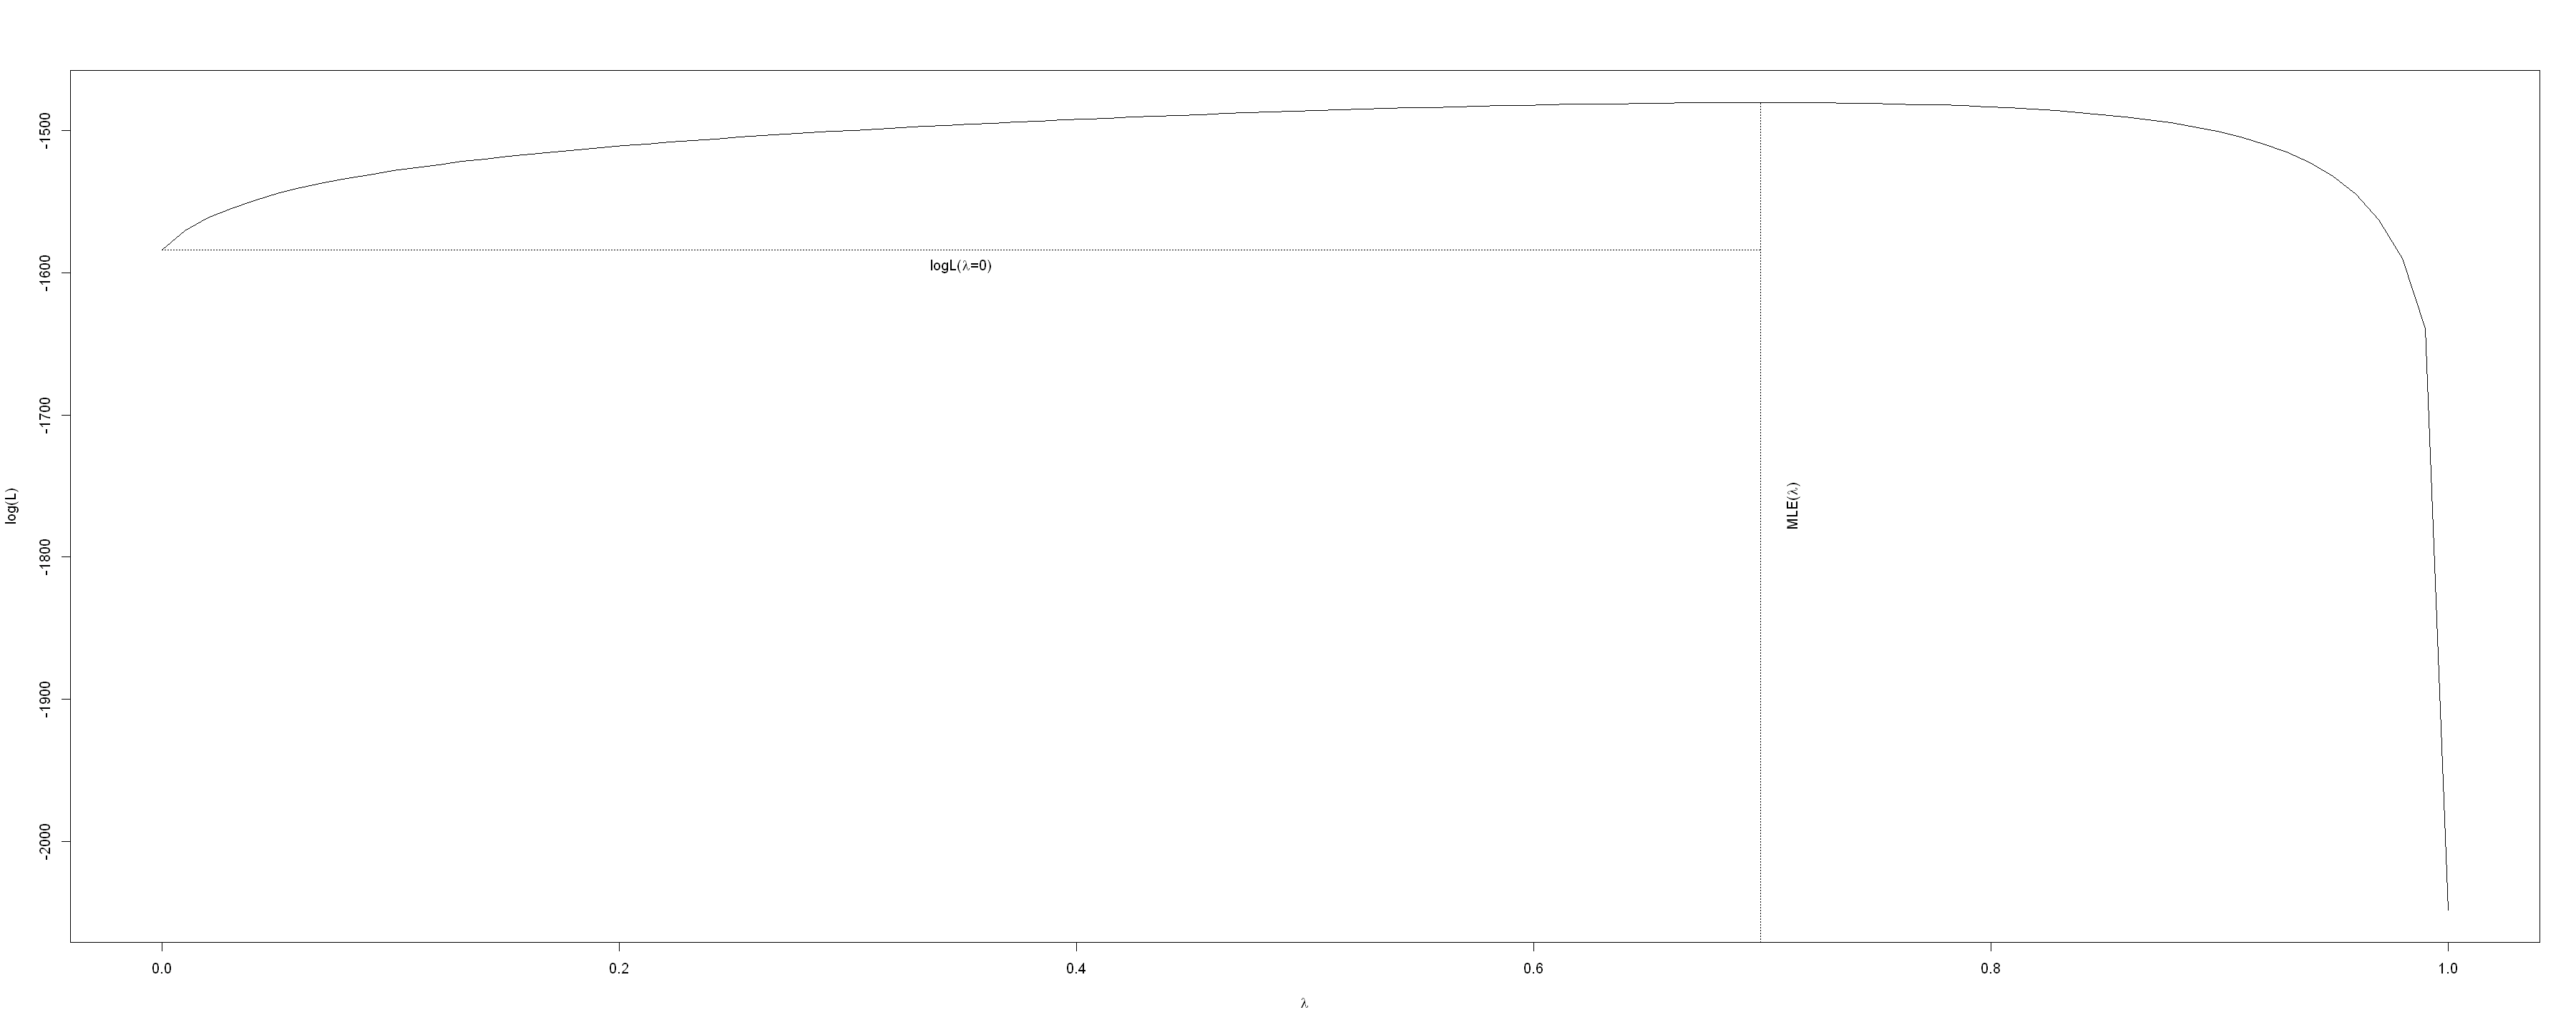

In [108]:
plot(pagels_srl)

In [11]:
paired_changes <- paired_dc_changes(phylogeny = phylogeny,
                                    rdextant = setNames(data$F00679, nm = data$binominal),
                                    srlextant = setNames(data$F00727, nm = data$binominal),
                                    discextant = setNames(data$state, nm = data$binominal),
                                    rdinternodes = ace_rd_995$ace,
                                    srlinternodes = ace_srl_995$ace,
                                    discprobinternodes = ace_5states_995_corhmm$states,
                                    discstates = CORHMM_5STATES_LEGEND)

In [12]:
head(paired_changes)

,shifts,delta_rd,delta_srl
,<chr>,<dbl>,<dbl>
1,AM_to_AM,0.002480619,0.006524816
2,AM_to_AM,-0.054448123,0.234665175
3,AM_to_AM,0.031589377,-0.056366143
4,AM_to_AM,0.003543559,-0.006095365
5,AM_to_AM,0.070699188,-0.072416572
6,AM_to_AM,0.020077742,-0.013665562


In [14]:
write.csv(paired_changes, file = "../../data/chapter2/FREDv3subset/deltalogaces995.csv", row.names = FALSE)

In [10]:
#----------------------------------------------------------------------
# CHANGES IN LOG RD WITH CORRESPONDING MYCORRHIZAL STATE TRANSITIONS
#----------------------------------------------------------------------

# the continuous trait change measured here is the (value of ancestor - value of descendant)
as.data.frame(lapply(split(paired_changes, ~shifts), FUN = function(df) { c(mean(df$delta_rd), sd(df$delta_rd)) }), row.names = c("mean", "std")) # summary

,AM_to_AM,AM_to_EcM,AM_to_EcMAM,AM_to_NM,AM_to_NMAM,EcM_to_AM,EcM_to_EcM,EcM_to_NMAM,EcMAM_to_AM,EcMAM_to_EcMAM,NM_to_NM,NMAM_to_AM,NMAM_to_EcM,NMAM_to_NMAM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,-0.00227363,0.001977551,-0.09102003,0.1945589,-0.009203943,0.00842402,0.001767719,0.3076190,0.1672044,0.0122208,0.009987086,-0.03364303,-0.28515146,0.01754058
std,0.24112662,0.277641482,0.37549041,0.3912832,0.301737926,NA,0.239752664,0.0653178,0.5360357,0.2559199,0.167460652,NA,0.07965926,0.27796834


In [11]:
#----------------------------------------------------------------------
# CHANGES IN LOG SRL WITH CORRESPONDING MYCORRHIZAL STATE TRANSITIONS
#----------------------------------------------------------------------

as.data.frame(lapply(split(paired_changes, ~shifts), FUN = function(df) { c(mean(df$delta_srl), sd(df$delta_srl)) }), row.names = c("mean", "std")) # summary

,AM_to_AM,AM_to_EcM,AM_to_EcMAM,AM_to_NM,AM_to_NMAM,EcM_to_AM,EcM_to_EcM,EcM_to_NMAM,EcMAM_to_AM,EcMAM_to_EcMAM,NM_to_NM,NMAM_to_AM,NMAM_to_EcM,NMAM_to_NMAM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,0.008940855,-0.02763368,0.4077492,-0.6446742,-0.1191378,0.05997439,-0.002312536,-0.4825296,-0.6171524,-0.05245372,-0.03312823,-0.08856933,0.7096372,-0.05777951
std,0.640810457,1.03544743,1.1579731,0.8756583,0.8972301,NA,0.462535553,2.3073945,1.8795482,0.55928409,0.29958555,NA,0.2485537,1.09449431


In [ ]:
# CONSIDER A VIOLIN PLOT INSTEAD OF REGULAR BOX PLOTS!!!!!!

In [40]:
sample_size_positions <- paired_changes %>% group_by(shifts) %>% summarize(n = n(), delta_rd = max(delta_rd) + 0.1, delta_srl = max(delta_srl) + 0.25)

In [26]:
# we need to convert the the dataset to a long format
long_format <- data.frame(shifts=c(paired_changes$shifts, paired_changes$shifts), delta=c(paired_changes$delta_rd, paired_changes$delta_srl), trait=c(rep("RD", times = length(paired_changes$delta_rd)),
                    rep("SRL", times = length(paired_changes$delta_srl))))

In [27]:
head(long_format)

,shifts,delta,trait
,<chr>,<dbl>,<chr>
1,AM_to_AM,0.002480619,RD
2,AM_to_AM,-0.054448123,RD
3,AM_to_AM,0.031589377,RD
4,AM_to_AM,0.003543559,RD
5,AM_to_AM,0.070699188,RD
6,AM_to_AM,0.020077742,RD
